In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap

In [2]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

print(df.head())
print(df.info())
print(df['churn'].value_counts())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    

In [3]:
#BASIC PREPROCESSING

# Drop customer_id (not useful for prediction)
df = df.drop("customer_id", axis=1)

# Label encoding for country, gender
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])
df['gender'] = le.fit_transform(df['gender'])

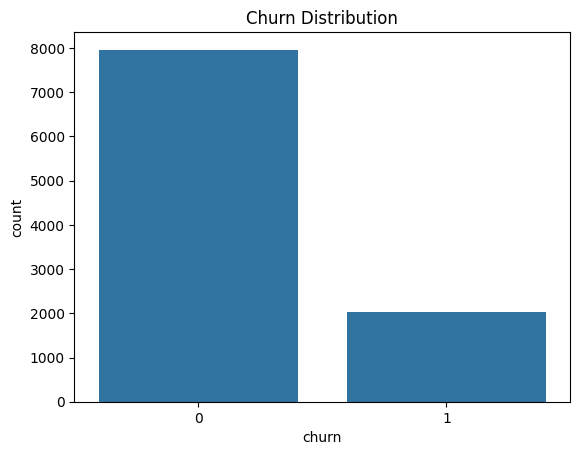

Imbalance ratio: 0.2037


In [4]:
# CHECK CLASS IMBALANCE
sns.countplot(x=df['churn'])
plt.title("Churn Distribution")
plt.show()

print("Imbalance ratio:", df['churn'].mean())

In [5]:
# SMOTE to handle imbalance
X = df.drop('churn', axis=1)
y = df['churn']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

After SMOTE: churn
1    7963
0    7963
Name: count, dtype: int64


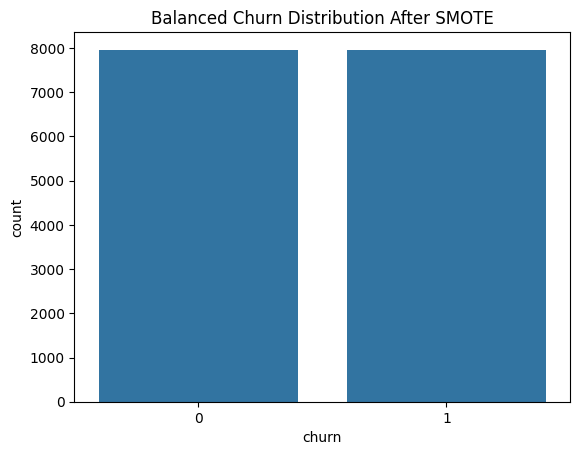

In [6]:
print("After SMOTE:", y_res.value_counts())

sns.countplot(x=y_res)
plt.title("Balanced Churn Distribution After SMOTE")
plt.show()

In [7]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [8]:
# XGBOOST MODEL

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
# PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [10]:
# METRICS
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("ROC-AUC:", roc)

Accuracy: 0.8575015693659761
Precision: 0.8502230720203952
Recall: 0.8589826142949131
F1-score: 0.8545803971812941
ROC-AUC: 0.9321539134299062


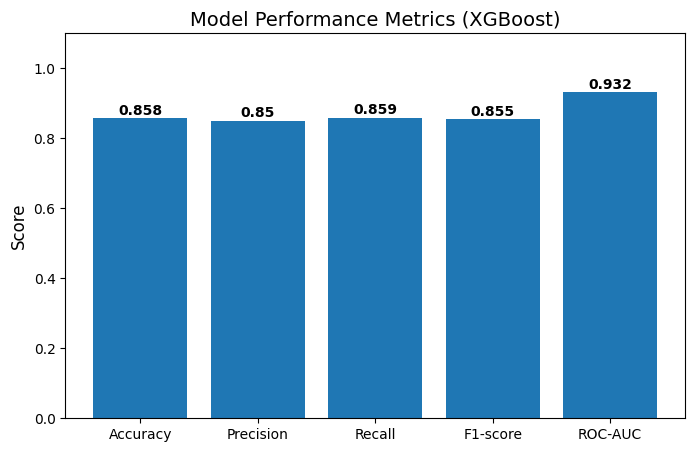

In [11]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metrics_values = [acc, prec, rec, f1, roc]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics_names, metrics_values)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             round(yval, 3), ha='center', fontsize=10, fontweight='bold')

plt.title("Model Performance Metrics (XGBoost)", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.1)
plt.show()

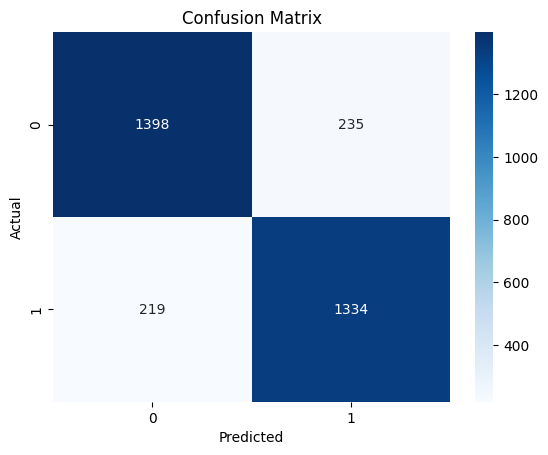

In [12]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

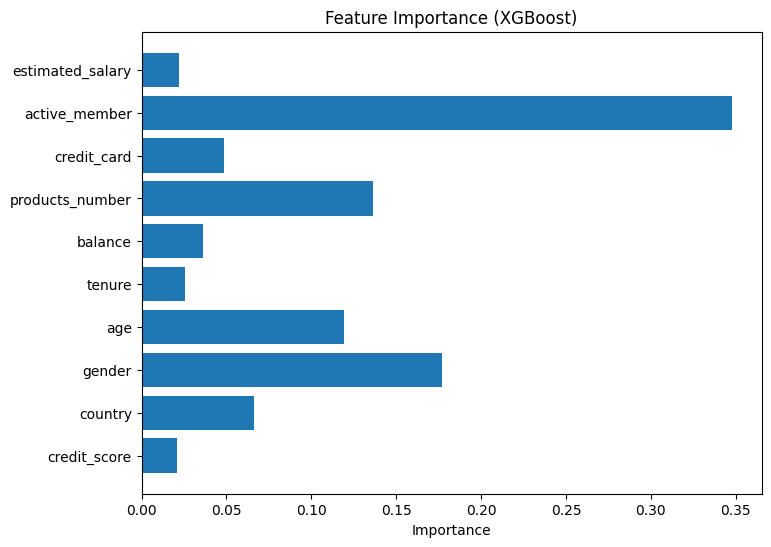

In [13]:
# FEATURE IMPORTANCE
plt.figure(figsize=(8,6))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

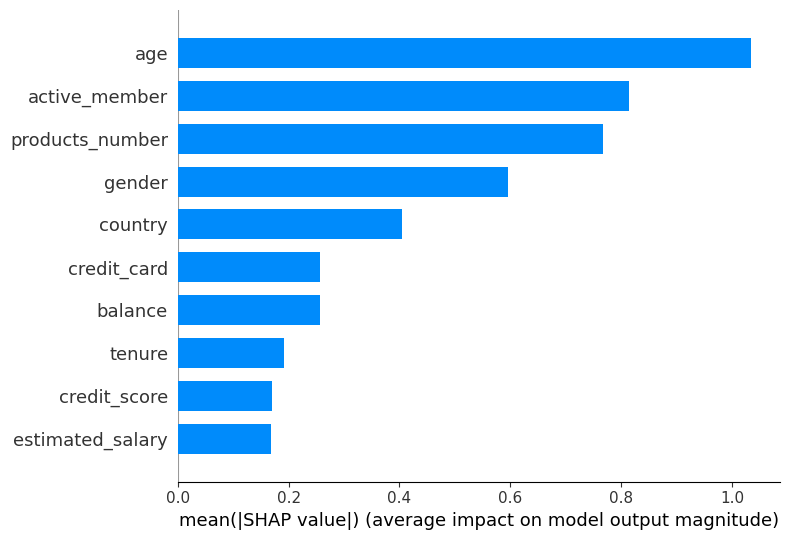

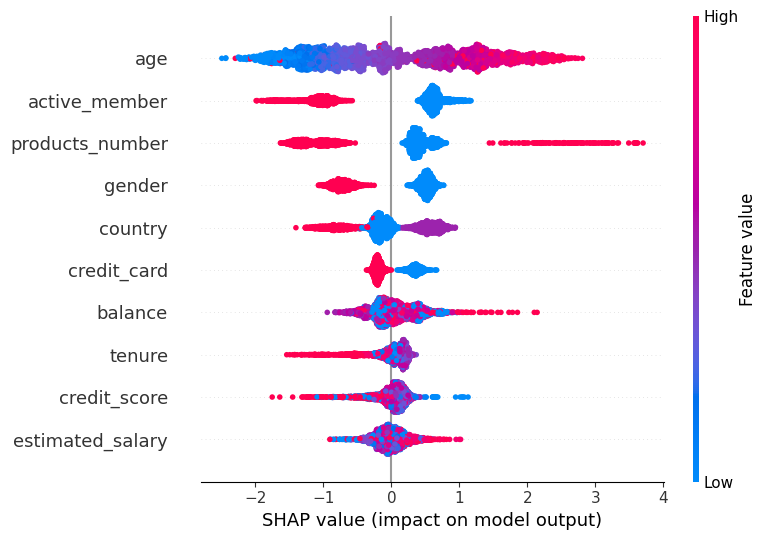

In [14]:
# SHAP EXPLAINABILITY
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)